In [1]:
import time
from pathlib import Path

import cv2
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ResNet-18

In [2]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(identity)

        out = out + identity
        out = self.relu(out)
        return out


In [3]:
class ResNet18Encoder(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 64, blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)

        self._init_weights()

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = [BasicBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x0 = self.relu(self.bn1(self.conv1(x)))  # [B, 64, H/2,  W/2]
        x1 = self.maxpool(x0)                    # [B, 64, H/4,  W/4]
        x1 = self.layer1(x1)                    # [B, 64, H/4,  W/4]
        x2 = self.layer2(x1)                    # [B,128, H/8,  W/8]
        x3 = self.layer3(x2)                    # [B,256, H/16, W/16]
        x4 = self.layer4(x3)                    # [B,512, H/32, W/32]
        return x0, x1, x2, x3, x4



In [4]:
class ResNet18Heatmap(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ResNet18Encoder(in_channels=1)

        self.up4 = self._up_block(512, 256)
        self.up3 = self._up_block(256 + 256, 128)
        self.up2 = self._up_block(128 + 128, 64)
        self.up1 = self._up_block(64 + 64, 64)

        self.head = nn.Sequential(
            nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.Tanh(),
        )

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        input_hw = x.shape[-2:]
        x0, x1, x2, x3, x4 = self.encoder(x)

        y = F.interpolate(x4, size=x3.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up4(y)

        y = torch.cat([y, x3], dim=1)
        y = F.interpolate(y, size=x2.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up3(y)

        y = torch.cat([y, x2], dim=1)
        y = F.interpolate(y, size=x1.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up2(y)

        y = torch.cat([y, x1], dim=1)
        y = F.interpolate(y, size=x0.shape[-2:], mode="bilinear", align_corners=False)
        y = self.up1(y)

        y = torch.cat([y, x0], dim=1)
        y = self.head(y)

        y = F.interpolate(y, size=input_hw, mode="bilinear", align_corners=False)
        return y


# Instantiate model

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet18Heatmap().to(DEVICE)

print(f"Model on device: {DEVICE}")
print(model)

Model on device: cuda
ResNet18Heatmap(
  (encoder): ResNet18Encoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-0

# Training setup

In [6]:
def total_variation_loss(x):
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    return dx + dy


def compute_composite_loss(
    pred,
    target,
    center_thr=0.3,
    edge_thr=-0.3,
    center_weight=3.0,
    edge_weight=2.0,
    bg_weight=1.0,
    edge_margin=0.1,
    lambda_reg=1.0,
    lambda_edge=0.2,
    lambda_tv=1e-5,
):
    pixel_loss = criterion(pred, target)
    weight = torch.full_like(target, bg_weight)

    center_mask = target > center_thr
    edge_mask = target < edge_thr

    weight[center_mask] = center_weight
    weight[edge_mask] = edge_weight
    reg_loss = (pixel_loss * weight).mean()

    if edge_mask.any():
        edge_pred = pred[edge_mask]
        edge_sign_loss = torch.relu(edge_pred + edge_margin).mean()
    else:
        edge_sign_loss = pred.new_tensor(0.0)

    tv_loss = total_variation_loss(pred)
    loss = lambda_reg * reg_loss + lambda_edge * edge_sign_loss + lambda_tv * tv_loss
    return loss, reg_loss.detach(), edge_sign_loss.detach(), tv_loss.detach()


def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_reg = 0.0
    total_edge = 0.0
    total_tv = 0.0

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        preds = model(images)
        loss, reg_l, edge_l, tv_l = compute_composite_loss(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_reg += reg_l.item()
        total_edge += edge_l.item()
        total_tv += tv_l.item()

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Batch {batch_idx + 1}: "
                f"total={loss.item():.4f}, reg={reg_l.item():.4f}, "
                f"edge={edge_l.item():.4f}, tv={tv_l.item():.4f}"
            )

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "reg": total_reg / n,
        "edge": total_edge / n,
        "tv": total_tv / n,
    }


@torch.no_grad()
def validate_one_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_reg = 0.0
    total_edge = 0.0
    total_tv = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        preds = model(images)
        loss, reg_l, edge_l, tv_l = compute_composite_loss(preds, targets)

        total_loss += loss.item()
        total_reg += reg_l.item()
        total_edge += edge_l.item()
        total_tv += tv_l.item()

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "reg": total_reg / n,
        "edge": total_edge / n,
        "tv": total_tv / n,
    }

In [7]:
criterion = nn.SmoothL1Loss(reduction='none')
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

# Dataset paths

In [8]:
def normalize01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = x.min(), x.max()
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)


def build_signed_target(mask: np.ndarray) -> np.ndarray:
    m = (mask > 0).astype(np.uint8)

    dist = cv2.distanceTransform(m, cv2.DIST_L2, 3).astype(np.float32)
    center = dist / dist.max() if dist.max() > 0 else np.zeros_like(dist, dtype=np.float32)

    kernel = np.ones((3, 3), np.uint8)
    edge = cv2.morphologyEx(m, cv2.MORPH_GRADIENT, kernel).astype(bool)

    target = center
    target[edge] = -1.0
    target[m == 0] = 0.0
    return np.clip(target, -1.0, 1.0).astype(np.float32)


class CellHeatmapDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

        mask_paths = list(MASKS_DIR.glob("*.tif"))
        self.mask_by_stem = {p.stem: p for p in mask_paths}

        self.pairs = [(p, self.mask_by_stem[p.stem]) for p in self.img_paths if p.stem in self.mask_by_stem]
        if len(self.pairs) == 0:
            raise RuntimeError("No matched image/mask pairs found between imgs_contrast and masks.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = tiff.imread(img_path)
        mask = tiff.imread(mask_path)

        img = normalize01(img)
        target = build_signed_target(mask)

        if self.transform is not None:
            aug = self.transform(image=img, mask=target)
            image = aug["image"]
            target = aug["mask"]
        else:
            image = torch.from_numpy(img).unsqueeze(0)
            target = torch.from_numpy(target)

        if target.ndim == 2:
            target = target.unsqueeze(0)

        return image.float(), target.float()

In [9]:
PROJECT_ROOT = Path.cwd().parent.parent.resolve()
IMGS_DIR = PROJECT_ROOT / "data" / "imgs_contrast"
MASKS_DIR = PROJECT_ROOT / "data" / "masks"

assert IMGS_DIR.exists(), f"Missing folder: {IMGS_DIR}"
assert MASKS_DIR.exists(), f"Missing folder: {MASKS_DIR}"

In [10]:
train_tf = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.05, 0.05),
        rotate=(-30, 30),
        shear=(-5, 5),
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.4
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(512, 512),
    ToTensorV2(),
])

In [11]:
all_img_paths = sorted(IMGS_DIR.glob("*.tif"))
if len(all_img_paths) == 0:
    raise RuntimeError(f"No images found in {IMGS_DIR}")

base_ds = CellHeatmapDataset(all_img_paths, transform=None)
n_total = len(base_ds)
n_val = max(1, int(0.2 * n_total))
n_train = n_total - n_val

In [12]:
g = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(base_ds, [n_train, n_val], generator=g)

train_img_paths = [base_ds.pairs[i][0] for i in train_subset.indices]
val_img_paths = [base_ds.pairs[i][0] for i in val_subset.indices]

train_dataset = CellHeatmapDataset(train_img_paths, transform=train_tf)
val_dataset = CellHeatmapDataset(val_img_paths, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

In [13]:
print(f"Matched pairs total: {n_total}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

x, y = next(iter(train_loader))
print("Batch image shape:", x.shape)
print("Batch target shape:", y.shape)
print("Target range:", float(y.min()), float(y.max()))

Matched pairs total: 127
Train: 102 | Val: 25
Batch image shape: torch.Size([8, 1, 512, 512])
Batch target shape: torch.Size([8, 1, 512, 512])
Target range: -1.0 1.0


# Fit

In [14]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    *,
    num_epochs=50,
    ckpt_dir=None,
    patience=10,
    min_delta=0.0,
):
    if ckpt_dir is None:
        ckpt_dir = PROJECT_ROOT / "checkpoints" / "resnet18_pure_torch"

    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    best_val = float("inf")
    best_path = ckpt_dir / "best_model.pth"
    last_path = ckpt_dir / "last_model.pth"
    log_path = ckpt_dir / "train_log.csv"

    wait = 0
    t0 = time.time()

    if not log_path.exists():
        log_path.write_text(
            "epoch,train_loss,val_loss,train_reg,val_reg,train_edge,val_edge,train_tv,val_tv,lr\n",
            encoding="utf-8",
        )

    for epoch in range(1, num_epochs + 1):
        train_m = train_one_epoch(model, train_loader, optimizer, device)
        val_m = validate_one_epoch(model, val_loader, device)

        scheduler.step()

        lr = optimizer.param_groups[0].get("lr", float("nan"))
        elapsed_min = (time.time() - t0) / 60.0
        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train={train_m['loss']:.4f} | val={val_m['loss']:.4f} | "
            f"lr={lr:.2e} | {elapsed_min:.1f} min"
        )

        torch.save(model.state_dict(), last_path)

        if val_m["loss"] < (best_val - min_delta):
            best_val = val_m["loss"]
            wait = 0
            torch.save(model.state_dict(), best_path)
            print(f"  -> saved best: {best_path}")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping: no val improvement in {patience} epochs")
                break

        with log_path.open("a", encoding="utf-8") as f:
            f.write(
                f"{epoch},{train_m['loss']:.6f},{val_m['loss']:.6f},"
                f"{train_m['reg']:.6f},{val_m['reg']:.6f},"
                f"{train_m['edge']:.6f},{val_m['edge']:.6f},"
                f"{train_m['tv']:.6f},{val_m['tv']:.6f},"
                f"{lr:.8e}\n"
            )

    return {
        "best_val_loss": best_val,
        "best_path": str(best_path),
        "last_path": str(last_path),
        "log_path": str(log_path),
    }


@torch.no_grad()
def show_predictions(model, dataloader, device, num_samples=3):
    model.eval()

    examples = []
    for images, _targets in dataloader:
        images = images.to(device)
        preds = model(images)

        images_cpu = images.detach().cpu()
        preds_cpu = preds.detach().cpu()

        for i in range(images_cpu.shape[0]):
            img_hw = images_cpu[i, 0].numpy()
            pred_hw = preds_cpu[i, 0].numpy()
            examples.append((img_hw, pred_hw))
            if len(examples) >= num_samples:
                break
        if len(examples) >= num_samples:
            break

    if len(examples) == 0:
        raise RuntimeError("No samples found in dataloader.")

    fig, axes = plt.subplots(len(examples), 2, figsize=(8, 3 * len(examples)))
    if len(examples) == 1:
        axes = [axes]

    for row, (img_hw, pred_hw) in enumerate(examples):
        ax_in, ax_out = axes[row]
        ax_in.imshow(img_hw, cmap="gray")
        ax_in.set_title("Input")
        ax_in.axis("off")

        im = ax_out.imshow(pred_hw, cmap="viridis", vmin=-1.0, vmax=1.0)
        ax_out.set_title("Predicted heatmap")
        ax_out.axis("off")
        fig.colorbar(im, ax=ax_out, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

Batch 10: total=0.0235, reg=0.0160, edge=0.0375, tv=0.0167
Epoch 001/50 | train=0.0374 | val=0.0346 | lr=1.00e-04 | 0.1 min
  -> saved best: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/checkpoints/resnet18_pure_torch/best_model.pth
Batch 10: total=0.0188, reg=0.0161, edge=0.0139, tv=0.0162
Epoch 002/50 | train=0.0184 | val=0.0316 | lr=9.99e-05 | 0.2 min
  -> saved best: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/checkpoints/resnet18_pure_torch/best_model.pth
Batch 10: total=0.0213, reg=0.0187, edge=0.0130, tv=0.0204
Epoch 003/50 | train=0.0175 | val=0.0258 | lr=9.98e-05 | 0.2 min
  -> saved best: /mnt/d_drive/Documentos/SPJain/Term6/ComputerVision/cell-tracking-challenge-cv-project/checkpoints/resnet18_pure_torch/best_model.pth
Batch 10: total=0.0181, reg=0.0146, edge=0.0176, tv=0.0160
Epoch 004/50 | train=0.0178 | val=0.0234 | lr=9.96e-05 | 0.3 min
  -> saved best: /mnt/d_drive/Documentos/SPJain/Ter

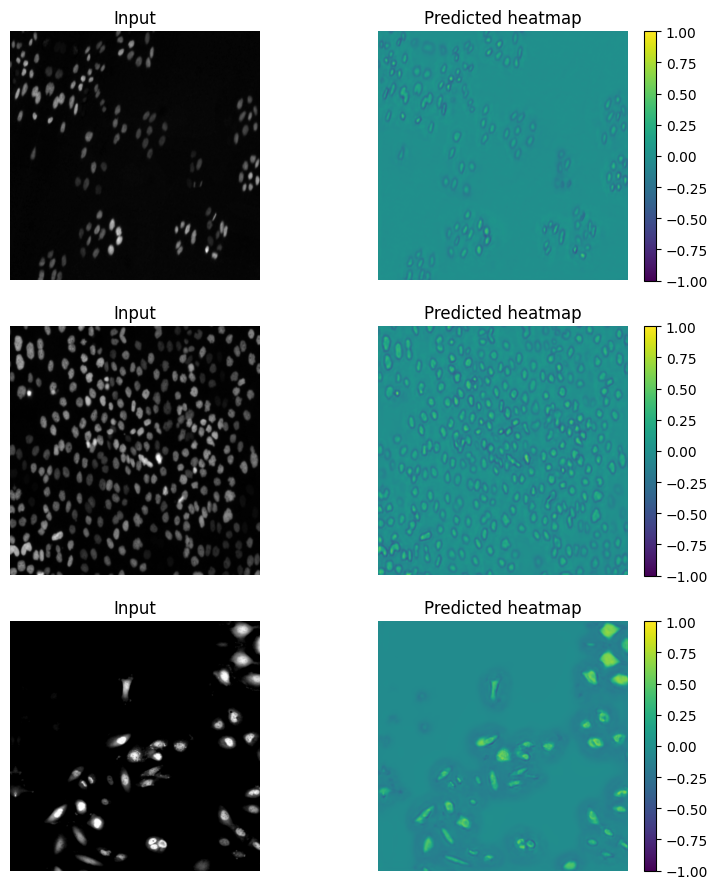

In [15]:
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=50,
    patience=10,
)
print(run_info)

show_predictions(model, train_loader, DEVICE, num_samples=3)